In [ ]:
import ast
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Plot insert and search times

In [5]:
benchmark_rows = []

with open("benchmark_results.text", "r") as f:
    lines = f.readlines()[1:]  # skip header

for line in lines:
    line = line.strip()
    # Skip empty lines
    if not line:
        continue
    # Find the first "{"
    start = line.find("{")
    # Extract only the dictionary portion
    dict_part = line[start:]
    # Convert safely to Python dict
    benchmark_rows.append(ast.literal_eval(dict_part))

bench_df = pd.DataFrame(benchmark_rows)

print(bench_df.head())

         dataset  items  insert_time  lookup_time
0  english_words   1000     0.003315     0.004652
1  english_words  10000     0.028309     0.032489
2  english_words  50000     0.136129     0.166881
3      sentences    100     0.000290     0.000304
4      sentences   1000     0.002687     0.003060


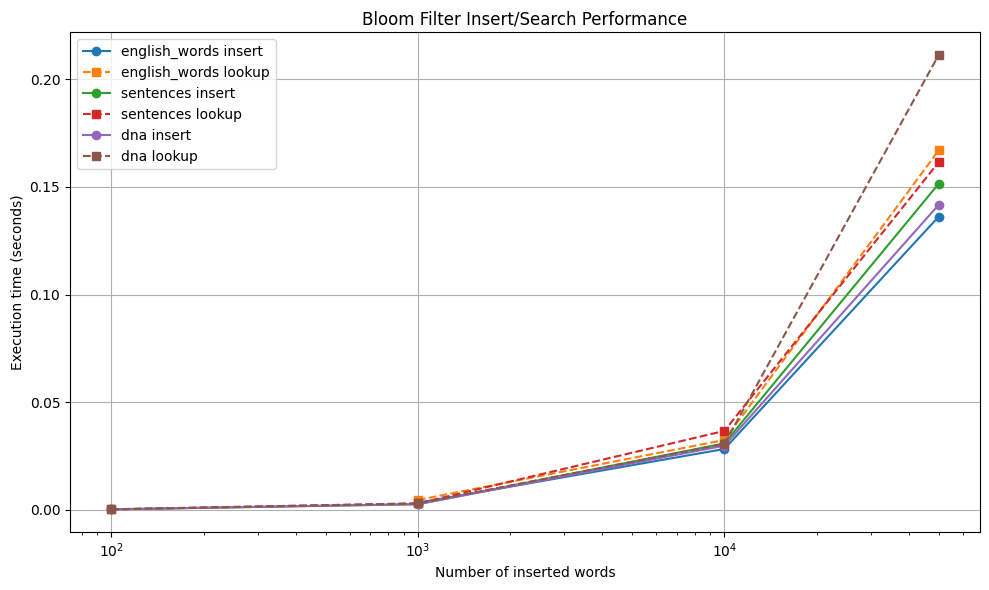

In [7]:

plt.figure(figsize=(10, 6))

datasets = bench_df["dataset"].unique()

for dataset in datasets:
    subset = bench_df[bench_df["dataset"] == dataset]

    plt.plot(
        subset["items"],
        subset["insert_time"],
        marker="o",
        label=f"{dataset} insert"
    )

    plt.plot(
        subset["items"],
        subset["lookup_time"],
        marker="s",
        linestyle="--",
        label=f"{dataset} lookup"
    )

plt.xscale("log")

plt.xlabel("Number of inserted words")
plt.ylabel("Execution time (seconds)")
plt.title("Bloom Filter Insert/Search Performance")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("benchmark_times.png", dpi=300)


# Plot FPR

In [7]:

with open("fpr_results.json", "r") as f:
    fpr_data = json.load(f)

fpr_df = pd.DataFrame(fpr_data)


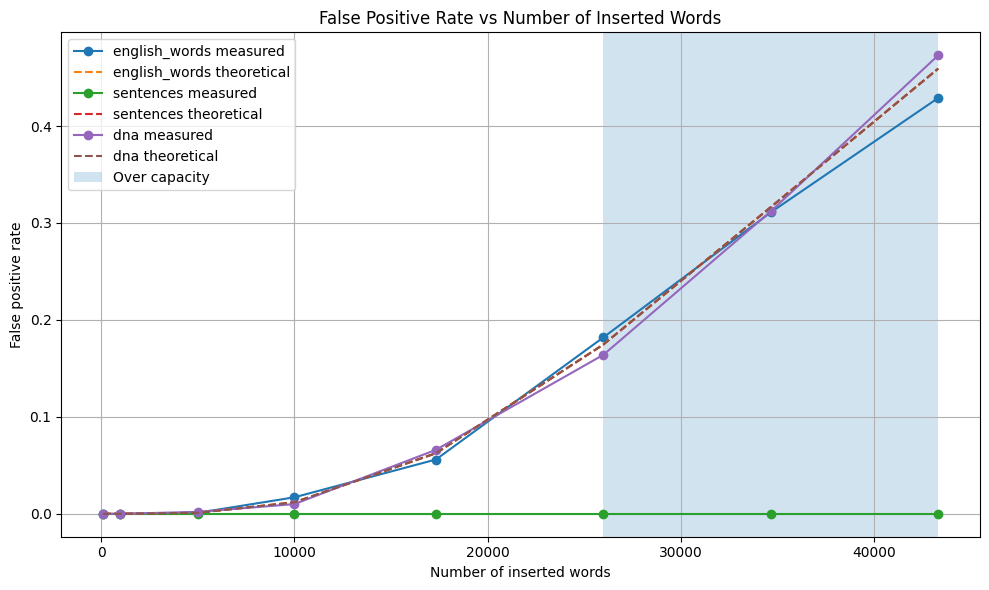

In [10]:
plt.figure(figsize=(10, 6))

for dataset in fpr_df["dataset"].unique():

    subset = fpr_df[fpr_df["dataset"] == dataset]

    plt.plot(
        subset["n_inserted"],
        subset["fpr_measured"],
        marker="o",
        label=f"{dataset} measured"
    )

    plt.plot(
        subset["n_inserted"],
        subset["fpr_theoretical"],
        linestyle="--",
        label=f"{dataset} theoretical"
    )

# highlight over-capacity region
over = fpr_df[fpr_df["over_capacity"] == True]

if not over.empty:
    plt.axvspan(
        over["n_inserted"].min(),
        over["n_inserted"].max(),
        alpha=0.2,
        label="Over capacity"
    )

plt.xlabel("Number of inserted words")
plt.ylabel("False positive rate")
plt.title("False Positive Rate vs Number of Inserted Words")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("false_positive_rate.png", dpi=300)

# Comression rate

compression_rate = bloom_filter_size_bits / exact_storage_bits

Exact storage estimate: average_word_length * 8 bits

Bloom filter size formula:
$$m = -(n * ln(p)) / (ln(2)^2)$$

where:
    $n$ = expected number of items
    $p$ = desired false positive probability

In [12]:
with open("compression_results.json", "r") as f:
    compr_data = json.load(f)

compr_df = pd.DataFrame(compr_data)
compr_df.columns

Index(['dataset', 'n_inserted', 'fpr_target', 'm_bits', 'k_hashes',
       'bits_per_element', 'naive_set_bits', 'compression_ratio',
       'fpr_measured', 'fpr_theoretical'],
      dtype='str')

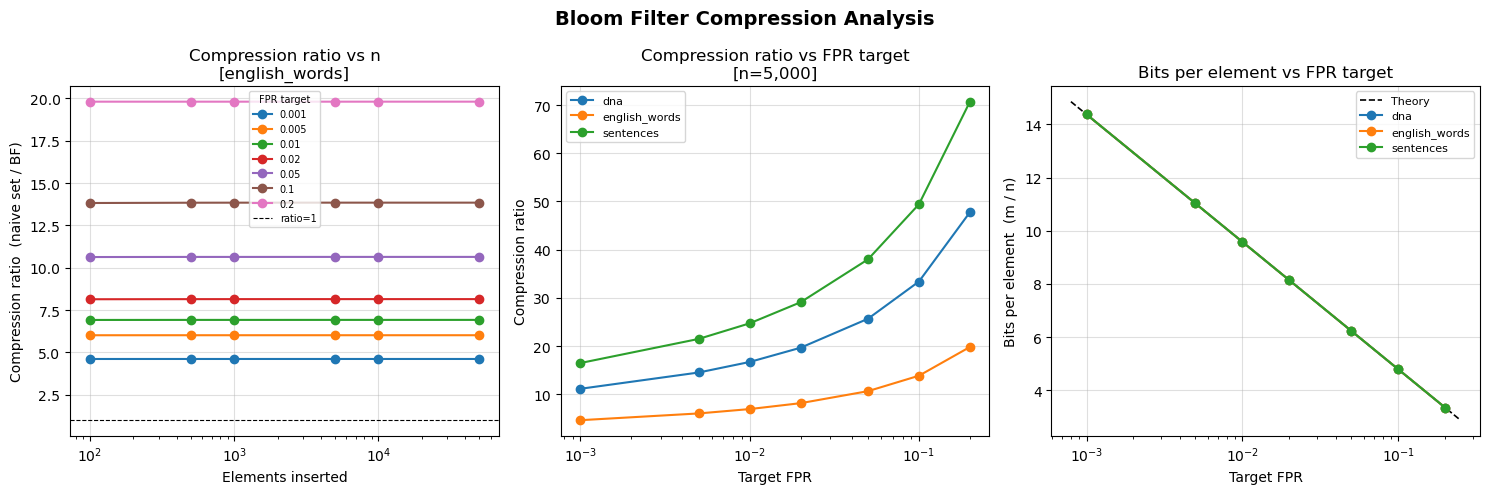

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Bloom Filter Compression Analysis", fontsize=14, fontweight="bold")

# P1 compression ratio vs n, one line per FPR target (english_words)
ax = axes[0]
df = compr_df[compr_df["dataset"] == "english_words"]
for fpr_t, group in df.groupby("fpr_target"):
    group = group.sort_values("n_inserted")
    ax.plot(group["n_inserted"], group["compression_ratio"], "o-", label=f"{fpr_t}")
ax.axhline(1, color="black", linestyle="--", linewidth=0.8, label="ratio=1")
ax.set_xscale("log")
ax.set_xlabel("Elements inserted")
ax.set_ylabel("Compression ratio  (naive set / BF)")
ax.set_title("Compression ratio vs n\n[english_words]")
ax.legend(title="FPR target", fontsize=7, title_fontsize=7)
ax.grid(True, alpha=0.4)

# P2 compression ratio vs FPR target
ax = axes[1]
mid_n = sorted(compr_df["n_inserted"].unique())[len(compr_df["n_inserted"].unique()) // 2]
df = compr_df[compr_df["n_inserted"] == mid_n]
for ds, group in df.groupby("dataset"):
    group = group.sort_values("fpr_target")
    ax.plot(group["fpr_target"], group["compression_ratio"], "o-", label=ds)
ax.set_xscale("log")
ax.set_xlabel("Target FPR")
ax.set_ylabel("Compression ratio")
ax.set_title(f"Compression ratio vs FPR target\n[n={mid_n:,}]")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

# P3 bits per element vs FPR target + theory
ax = axes[2]
fpr_cont = np.logspace(-3.1, -0.6, 200)
ax.plot(fpr_cont, -np.log(fpr_cont) / math.log(2)**2,
        "--", color="black", linewidth=1.2, label="Theory")
df = compr_df[compr_df["n_inserted"] == mid_n]
for ds, group in df.groupby("dataset"):
    group = group.sort_values("fpr_target")
    ax.plot(group["fpr_target"], group["bits_per_element"], "o-", label=ds)
ax.set_xscale("log")
ax.set_xlabel("Target FPR")
ax.set_ylabel("Bits per element  (m / n)")
ax.set_title("Bits per element vs FPR target")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("compression_analysis.png", dpi=300)
plt.show()